# Figure 2 : B16-TST-TIM Parameter fitting results

In [1]:
from scipy.integrate import odeint
from scipy.optimize import differential_evolution
from matplotlib.ticker import ScalarFormatter

In [2]:
%run 00_data_preprocessing.ipynb

In [3]:
dir_path = "results/figures/section2/"
os.makedirs(dir_path, exist_ok=True)

# Model construction

## Model1
\begin{align*}
\frac{dV}{dt} &= v_r V \log\left(\frac{v_k}{V}\right) - k_s S V \\
\frac{dE}{dt} &= F(t) + \frac{e_p E V^2}{V^2 + k_v} - d_m M E - d_e E \\
\frac{dD}{dt} &= d_m M E + d_e E - d_d D \\
\frac{dS}{dt} &= E - d_s S \\
\frac{dM}{dt} &= m_f F(t) + m_v V - m_d M
\end{align*}


## Model2
\begin{align*}
\frac{dV}{dt} &= v_r V \log\left(\frac{v_k}{V}\right) - k_s S V \\
\frac{dE}{dt} &= F(t) + \frac{e_p E V^2}{V^2 + k_v} - \frac{d_m M E}{k_m + M} - d_e E \\
\frac{dD}{dt} &= \frac{d_m M E}{k_m + M} + d_e E - d_d D \\
\frac{dS}{dt} &= E - d_s S \\
\frac{dM}{dt} &= m_f F(t) + m_v V - m_d M
\end{align*}

## Parameter

$k_s$ corresponds to $v_s$ in the paper.

## Model Construction

In [4]:
t_start = 2  # Delay (in days) before TSTs infiltrate the tumor after injection

def tst_pulse(t, dose_list, dose_days, delta_t):
    """Return the TST input function F(t), based on dose schedule and delivery window."""
    total = 0
    for dose, day in zip(dose_list, dose_days):
        if day + t_start <= t < day + t_start + delta_t:
            total += dose / delta_t
    return total

In [5]:
## Model1: Lunear Suppression by MDSCs
def model1(y, t, dose_list, dose_days, delta_t, params):
    k_s, e_p, d_e, d_d, d_s, d_m, m_f = params
    V, E, D, S, M = y
    F_t = tst_pulse(t, dose_list, dose_days, delta_t)

    # ===ODE Model===
    #dVdt = v_r * V * np.log(v_k / V) - k_s * S * V
    if V <= 0:
        dVdt = 0  
    else:
        dVdt = v_r * V * np.log(v_k / V) - k_s * S * V

    dEdt = F_t + e_p * E * V**2 / (V**2 + k_v) - d_m * M * E - d_e * E
    dDdt = d_m * M * E + d_e * E - d_d * D
    dSdt = E - d_s * S
    dMdt = m_f * F_t + m_v * V - m_d * M

    return [dVdt, dEdt, dDdt, dSdt, dMdt]

In [6]:
# Model2: Saturable Suppression by MDSCs
def model2(y, t, dose_list, dose_days, delta_t, params):
    k_s, e_p, d_e, d_d, d_s, d_m, m_f, k_m = params
    V, E, D, S, M = y
    F_t = tst_pulse(t, dose_list, dose_days, delta_t)

    # ===ODE Model===
    # dVdt = v_r * V * np.log(v_k / V) - k_s * S * V
    if V <= 0:
        dVdt = 0  
    else:
        dVdt = v_r * V * np.log(v_k / V) - k_s * S * V
    dEdt = F_t + e_p * E * V**2 / (V**2 + k_v)  - d_m * E * M /(k_m+M) - d_e * E
    dDdt = d_m * E * M /(k_m+M) + d_e * E - d_d * D
    dSdt = E - d_s * S
    dMdt = m_f * F_t + m_v * V - m_d * M

    return [dVdt, dEdt, dDdt, dSdt, dMdt]

## visualization function

In [7]:
def set_scientific_yticks(ax):
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

# Plot with ACT fitting data
def vis_act_fit(sol, out_dir=None, figure_name=None):
    V_sol, E_sol, D_sol, S_sol, M_sol = sol.T
    T_sol = E_sol + D_sol

    # === Plot ===
    plt.figure(figsize=(16, 4), dpi=200)
    plt.rcParams["font.size"] = 12

    # --- Panel A: Tumor volume ---
    ax1 = plt.subplot(1, 4, 1)
    ax1.plot(t_eval, V_sol, label='Model', color='blue', linewidth=2)
    ax1.errorbar(v_days, v_data, yerr=v_std, fmt='o', color='black',
                 capsize=3, markersize=3, label='Data')
    ax1.set_xlabel("Days")
    ax1.set_ylabel("B16 (cells)")
    ax1.set_title("B16 Dynamics")
    ax1.legend()
    set_scientific_yticks(ax1)

    # --- Panel B: TIM ---
    ax2 = plt.subplot(1, 4, 2)
    ax2.plot(t_eval, M_sol, label='Model', color='blue')
    ax2.errorbar(mdsc_days, mdsc_data, yerr=mdsc_std, fmt='o', color='black',
                 capsize=3, markersize=3, label='Data')
    ax2.set_xlabel("Days")
    ax2.set_ylabel("TIM (cells)")
    ax2.set_title("TIM Dynamics")
    ax2.legend()
    set_scientific_yticks(ax2)

    # --- Panel C: TST ---
    ax3 = plt.subplot(1, 4, 3)
    ax3.plot(t_eval, T_sol, label='Total (E+D)', color='blue', linewidth=2)
    ax3.plot(t_eval, E_sol, label='Effector (E)', color='skyblue', linewidth=2)
    ax3.plot(t_eval, D_sol, label='Exhausted (D)', color='gray', linewidth=2)
    ax3.errorbar(ctl_days, ctl_data, yerr=ctl_std, fmt='o', color='black',
                 capsize=3, markersize=3, label='Data')
    ax3.set_xlabel('Days')
    ax3.set_ylabel('TST (cells)')
    ax3.set_title('TST Dynamics')
    ax3.legend()
    set_scientific_yticks(ax3)

    # --- Panel D: Suppression Effect ---
    ax4 = plt.subplot(1, 4, 4)
    ax4.plot(t_eval, S_sol, label='Model', color='blue', linewidth=2)
    ax4.set_xlabel('Days')
    ax4.set_ylabel('Tumor Suppression (S)')
    ax4.set_title('Tumor Suppression (S)')
    ax4.legend()
    set_scientific_yticks(ax4)

    plt.tight_layout()

    # === Save if out_dir is provided ===
    if out_dir is not None and figure_name is not None:
        os.makedirs(out_dir, exist_ok=True)
        pdf_path = os.path.join(out_dir, f"{figure_name}.pdf")
        jpeg_path = os.path.join(out_dir, f"{figure_name}.jpeg")
        plt.savefig(pdf_path, dpi=300)
        plt.savefig(jpeg_path, dpi=300)
        print(f"Figure saved: {pdf_path}, {jpeg_path}")

    plt.show()

In [8]:
def vis_act(sol, out_dir=None, figure_name=None):
    V_sol, E_sol, D_sol, S_sol, M_sol = sol.T
    T_sol = E_sol + D_sol

    # === Plot ===
    plt.figure(figsize=(16, 4), dpi=200)
    plt.rcParams["font.size"] = 12

    # --- Panel A: Tumor volume ---
    ax1 = plt.subplot(1, 4, 1)
    ax1.plot(t_eval, V_sol, label='Model', color='blue', linewidth=2)
    ax1.set_xlabel("Days")
    ax1.set_ylabel("B16 (cells)")
    ax1.set_title("B16 Dynamics")
    ax1.legend()
    set_scientific_yticks(ax1)

    # --- Panel B: TIM ---
    ax2 = plt.subplot(1, 4, 2)
    ax2.plot(t_eval, M_sol, label='Model', color='blue')
    ax2.set_xlabel("Days")
    ax2.set_ylabel("TIM (cells)")
    ax2.set_title("TIM Dynamics")
    ax2.legend()
    set_scientific_yticks(ax2)

    # --- Panel C: TST ---
    ax3 = plt.subplot(1, 4, 3)
    ax3.plot(t_eval, T_sol, label='Total (E+D)', color='blue', linewidth=2)
    ax3.plot(t_eval, E_sol, label='Effector (E)', color='skyblue', linewidth=2)
    ax3.plot(t_eval, D_sol, label='Exhausted (D)', color='gray', linewidth=2)
    ax3.set_xlabel('Days')
    ax3.set_ylabel('TST (cells)')
    ax3.set_title('TST Dynamics')
    ax3.legend()
    set_scientific_yticks(ax3)

    # --- Panel D: Suppression Effect ---
    ax4 = plt.subplot(1, 4, 4)
    ax4.plot(t_eval, S_sol, label='Model', color='blue', linewidth=2)
    ax4.set_xlabel('Days')
    ax4.set_ylabel('Tumor Suppression (S)')
    ax4.set_title('Tumor Suppression (S)')
    ax4.legend()
    set_scientific_yticks(ax4)

    plt.tight_layout()

    # === Save if out_dir is provided ===
    if out_dir is not None and figure_name is not None:
        os.makedirs(out_dir, exist_ok=True)
        pdf_path = os.path.join(out_dir, f"{figure_name}.pdf")
        jpeg_path = os.path.join(out_dir, f"{figure_name}.jpeg")
        plt.savefig(pdf_path, dpi=300)
        plt.savefig(jpeg_path, dpi=300)
        print(f"Figure saved: {pdf_path}, {jpeg_path}")

    plt.show()

# Parameter Optimization

## optimization function

In [9]:
param1 = np.array([
    1.3984e-07, 1.1920e+00, 9.2275e-01, 4.1533e-01,
    8.1198e-01, 3.4619e-08, 4.0161e+00
])

param2 = np.array([
    1.2699e-07, 1.5558e+00, 8.9530e-01, 4.9183e-01,
    7.6388e-01, 1.6922e+00, 3.9186e+00, 4.4873e+06
])

In [10]:
# ==Fixed param ==
v_r = 9.75e-2
v_k = 1.97e+10
m_v = 3.00e-2
m_d = 0.35

# Other article param
k_v = 2.02e7

# Figure S2. Optimization Results

Model1
Figure saved: results/figures/section2/figSa.pdf, results/figures/section2/figSa.jpeg


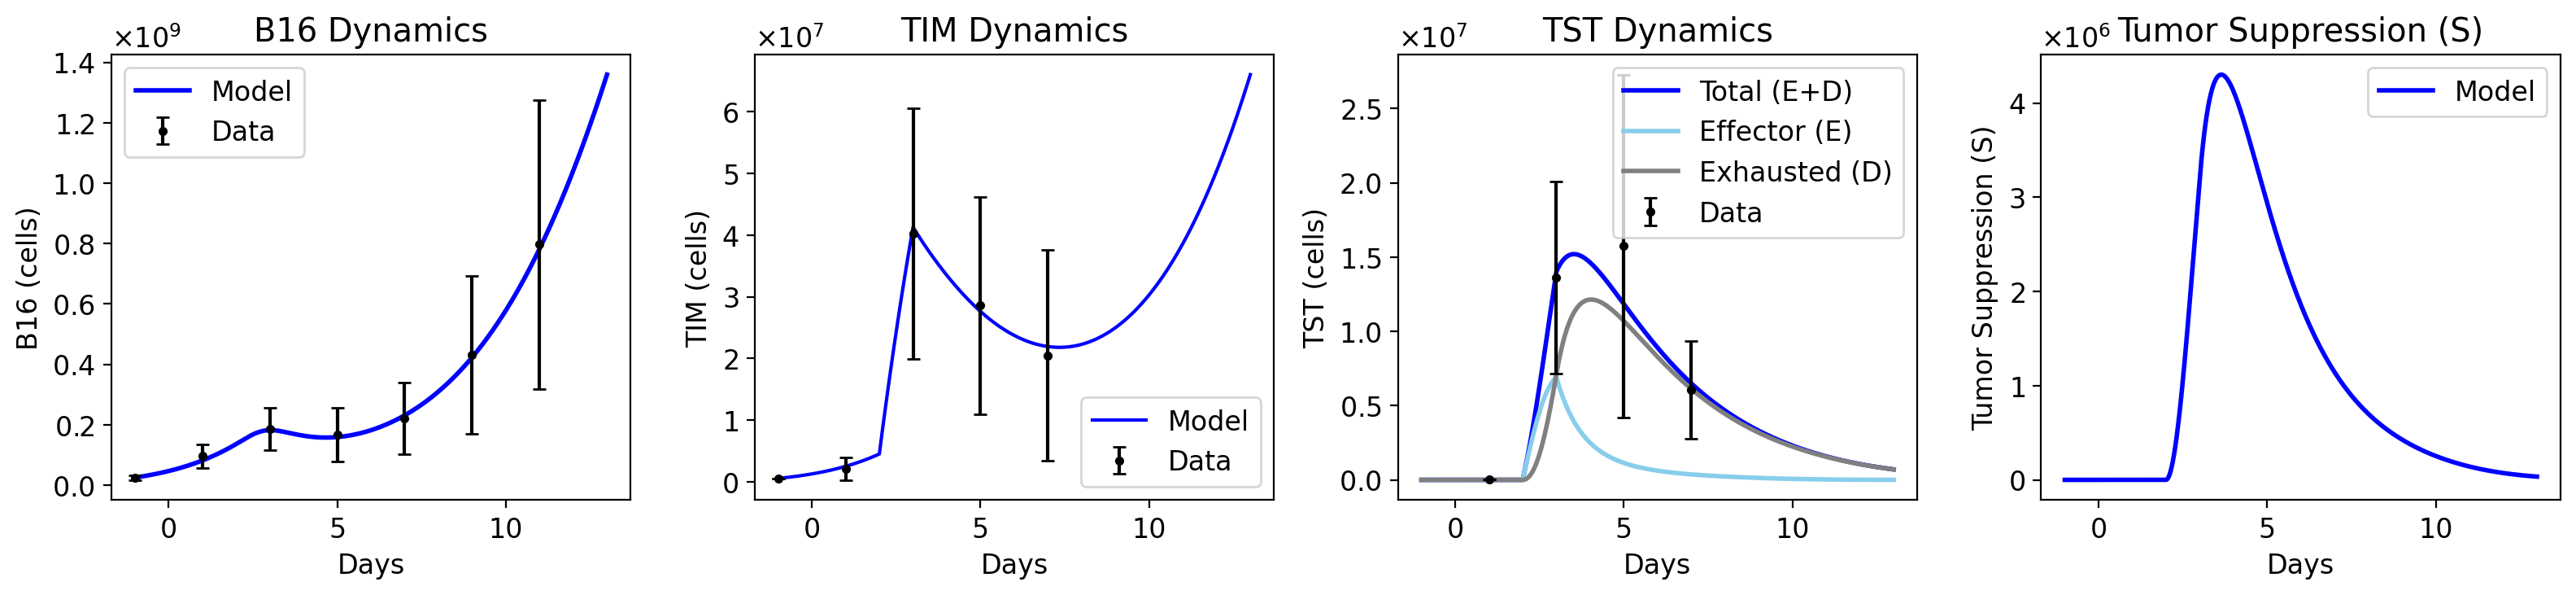

Model2
Figure saved: results/figures/section2/figSb.pdf, results/figures/section2/figSb.jpeg


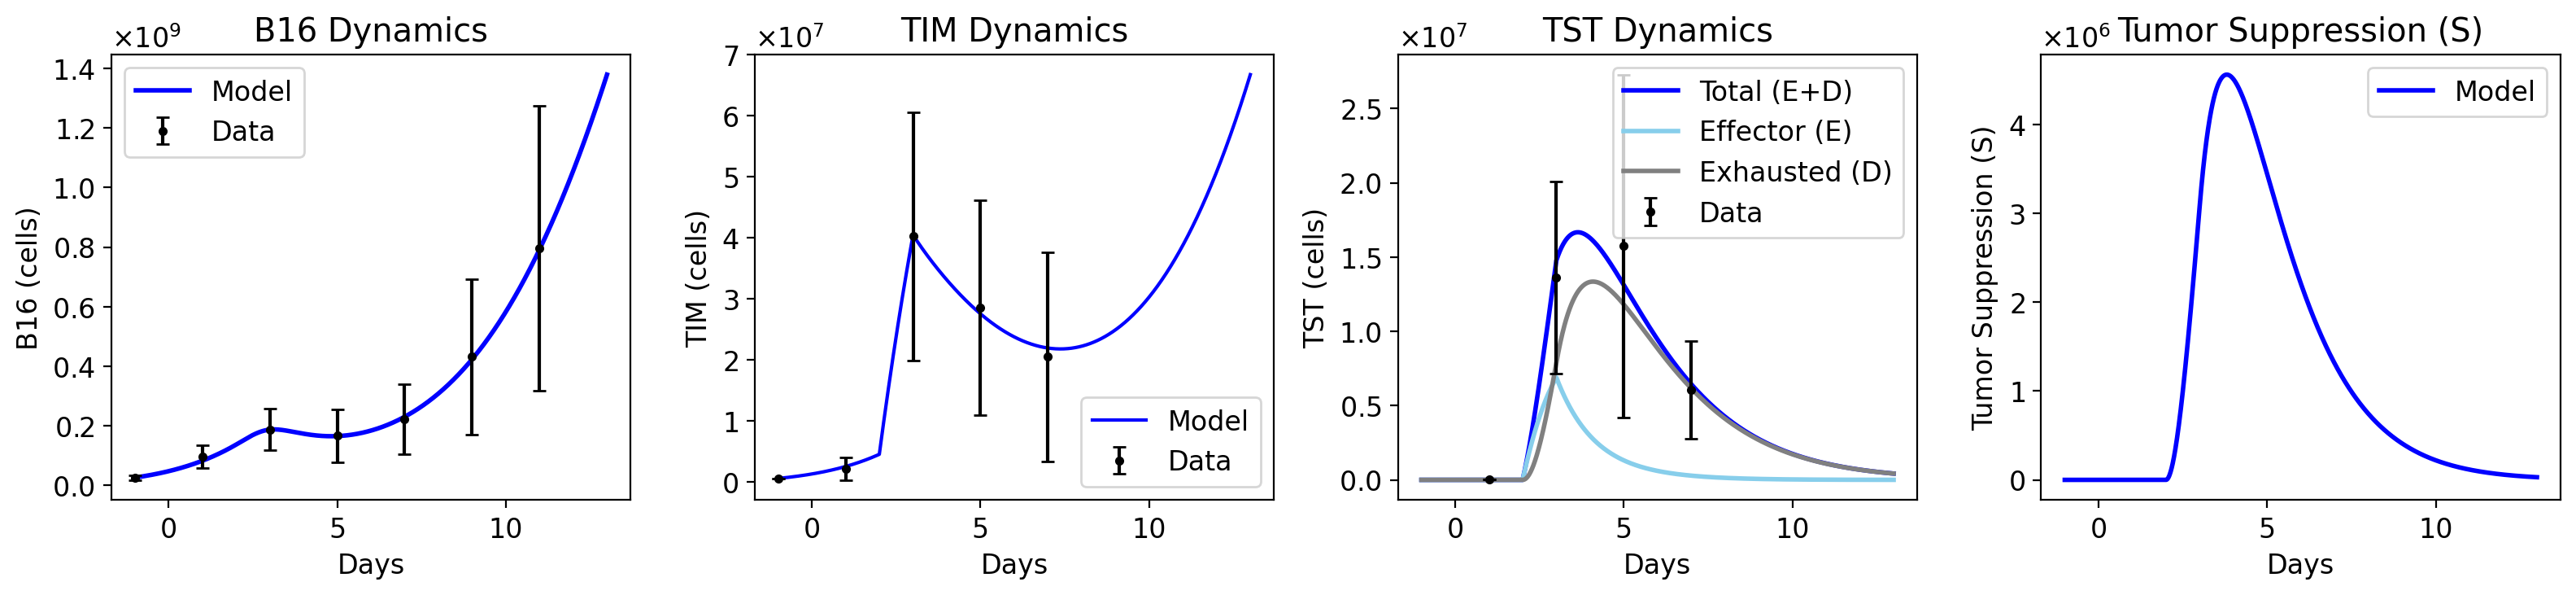

In [11]:
# Time range
y0 = [v_data[0], 0, 0, 0, mdsc_data[0]]
t_eval = np.arange(-1, 13.01, 0.01)

# Fixed TST injection schedule
dose_list = [1e7] 
dose_days = [0]    
delta_t = 1        

# === Model 1 Simulation ===
sol1 = odeint(model1, y0, t_eval, 
             args=(dose_list, dose_days, delta_t, param1),
             hmax=0.01)
V_sol1, E_sol1, D_sol1, S_sol1, M_sol1 = sol1.T
T_sol1 = E_sol1+D_sol1


# === Model 2 Simulation ===
sol2 = odeint(model2, y0, t_eval, 
             args=(dose_list, dose_days, delta_t, param2),
             hmax=0.01)
V_sol2, E_sol2, D_sol2, S_sol2, M_sol2 = sol2.T
T_sol2 = E_sol2+D_sol2

print("Model1")
vis_act_fit(sol1, dir_path, "figSa")
print("Model2")
vis_act_fit(sol2, dir_path, "figSb")

In [12]:
def set_scientific_yticks(ax):
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

# Plot with ACT fitting data
def vis_act_fit_v(sol, out_dir=None, figure_name=None):
    V_sol, E_sol, D_sol, S_sol, M_sol = sol.T
    T_sol = E_sol + D_sol

    # === Plot ===
    plt.figure(figsize=(8, 6), dpi=200)
    plt.rcParams["font.size"] = 12

    # --- Panel A: Tumor volume ---
    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(t_eval, V_sol, label='Model (V)', color='blue', linewidth=2)
    ax1.errorbar(v_days, v_data, yerr=v_std, fmt='o', color='black',
                 capsize=3, markersize=3, label='Data')
    ax1.set_xlabel("Days")
    ax1.set_ylabel("B16 (cells)")
   #ax1.set_title("B16 Dynamics")
    ax1.legend()
    set_scientific_yticks(ax1)

    # --- Panel B: MDSC ---
    ax2 = plt.subplot(2, 2, 2)
    ax2.plot(t_eval, M_sol, label='Model (M)', color='blue')
    ax2.errorbar(mdsc_days, mdsc_data, yerr=mdsc_std, fmt='o', color='black',
                 capsize=3, markersize=3, label='Data')
    ax2.set_xlabel("Days")
    ax2.set_ylabel("TIM (cells)")
    #ax2.set_title("MDSC Dynamics")
    ax2.legend()
    set_scientific_yticks(ax2)

    # --- Panel C: CTL ---
    ax3 = plt.subplot(2, 2, 3)
    ax3.plot(t_eval, T_sol, label='Total (E+D)', color='blue', linewidth=2)
    ax3.plot(t_eval, E_sol, label='Effector (E)', color='skyblue', linewidth=2)
    ax3.plot(t_eval, D_sol, label='Exhausted (D)', color='gray', linewidth=2)
    ax3.errorbar(ctl_days, ctl_data, yerr=ctl_std, fmt='o', color='black',
                 capsize=3, markersize=3, label='Data')
    ax3.set_xlabel('Days')
    ax3.set_ylabel('TST (cells)')
    #ax3.set_title('TST Dynamics')
    ax3.legend()
    set_scientific_yticks(ax3)

    # --- Panel D: Suppression Effect ---
    ax4 = plt.subplot(2, 2, 4)
    ax4.plot(t_eval, S_sol, label='Model (S)', color='blue', linewidth=2)
    ax4.set_xlabel('Days')
    ax4.set_ylabel('Tumor Suppression')
    #ax4.set_title('Tumor Suppression')
    ax4.legend()
    set_scientific_yticks(ax4)

    plt.tight_layout()

    # === Save if out_dir is provided ===
    if out_dir is not None and figure_name is not None:
        os.makedirs(out_dir, exist_ok=True)
        pdf_path = os.path.join(out_dir, f"{figure_name}.pdf")
        jpeg_path = os.path.join(out_dir, f"{figure_name}.jpeg")
        plt.savefig(pdf_path, dpi=300)
        plt.savefig(jpeg_path, dpi=300)
        print(f"Figure saved: {pdf_path}, {jpeg_path}")

    plt.show()

Model1
Figure saved: results/figures/section2/figSc.pdf, results/figures/section2/figSc.jpeg


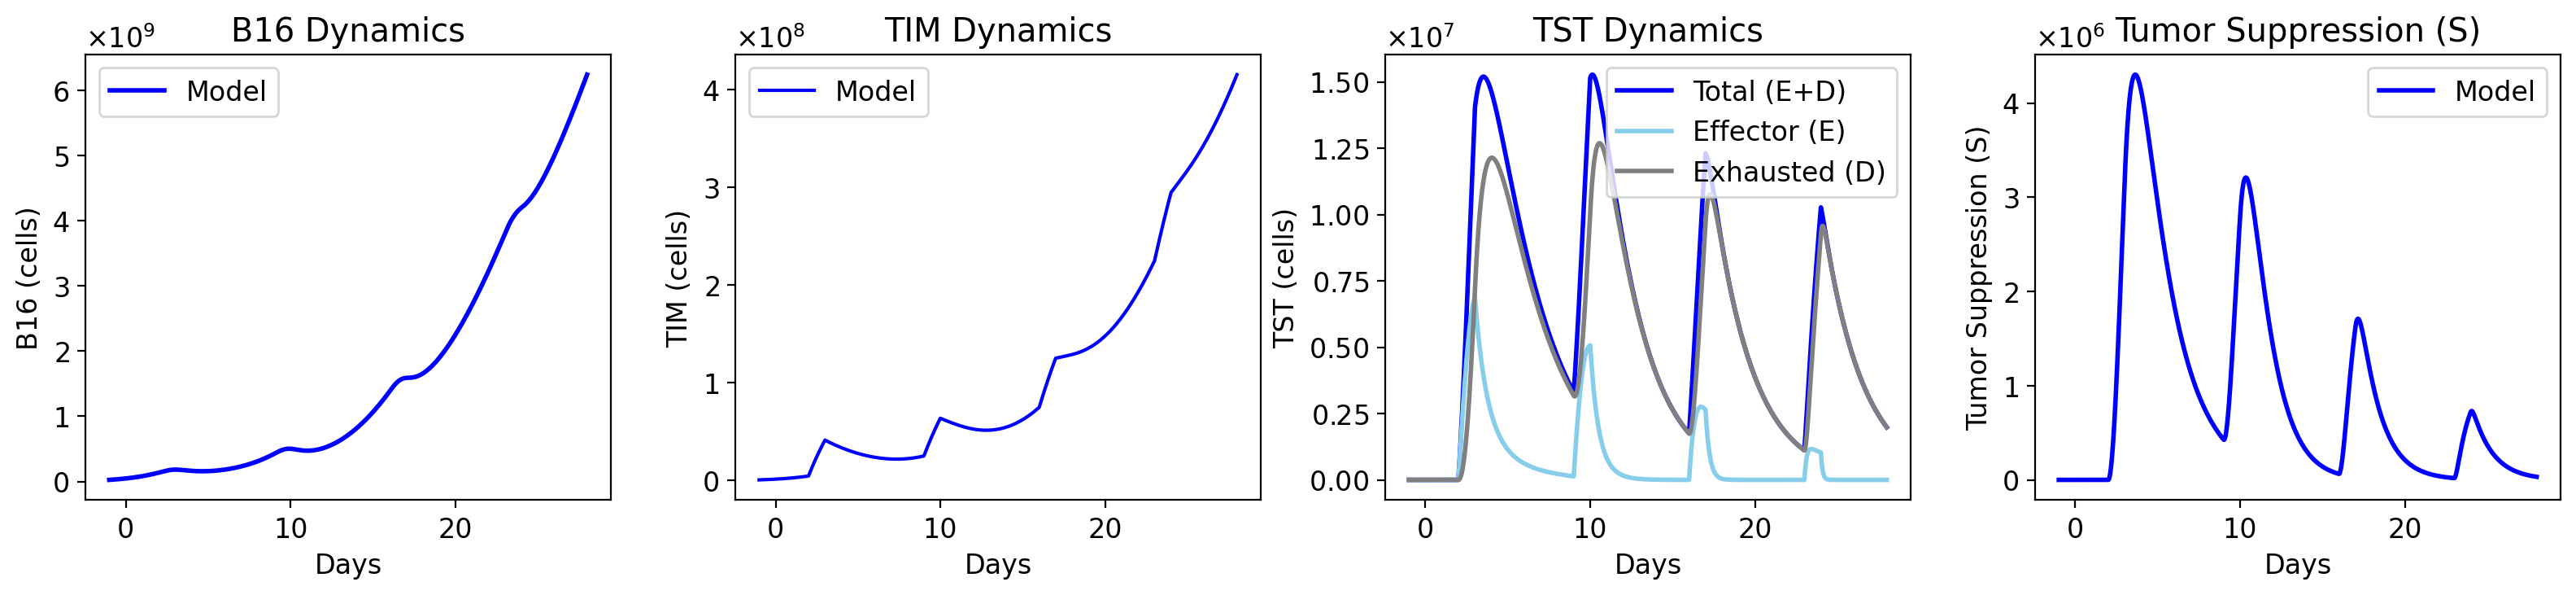

Model2
Figure saved: results/figures/section2/figSd.pdf, results/figures/section2/figSd.jpeg


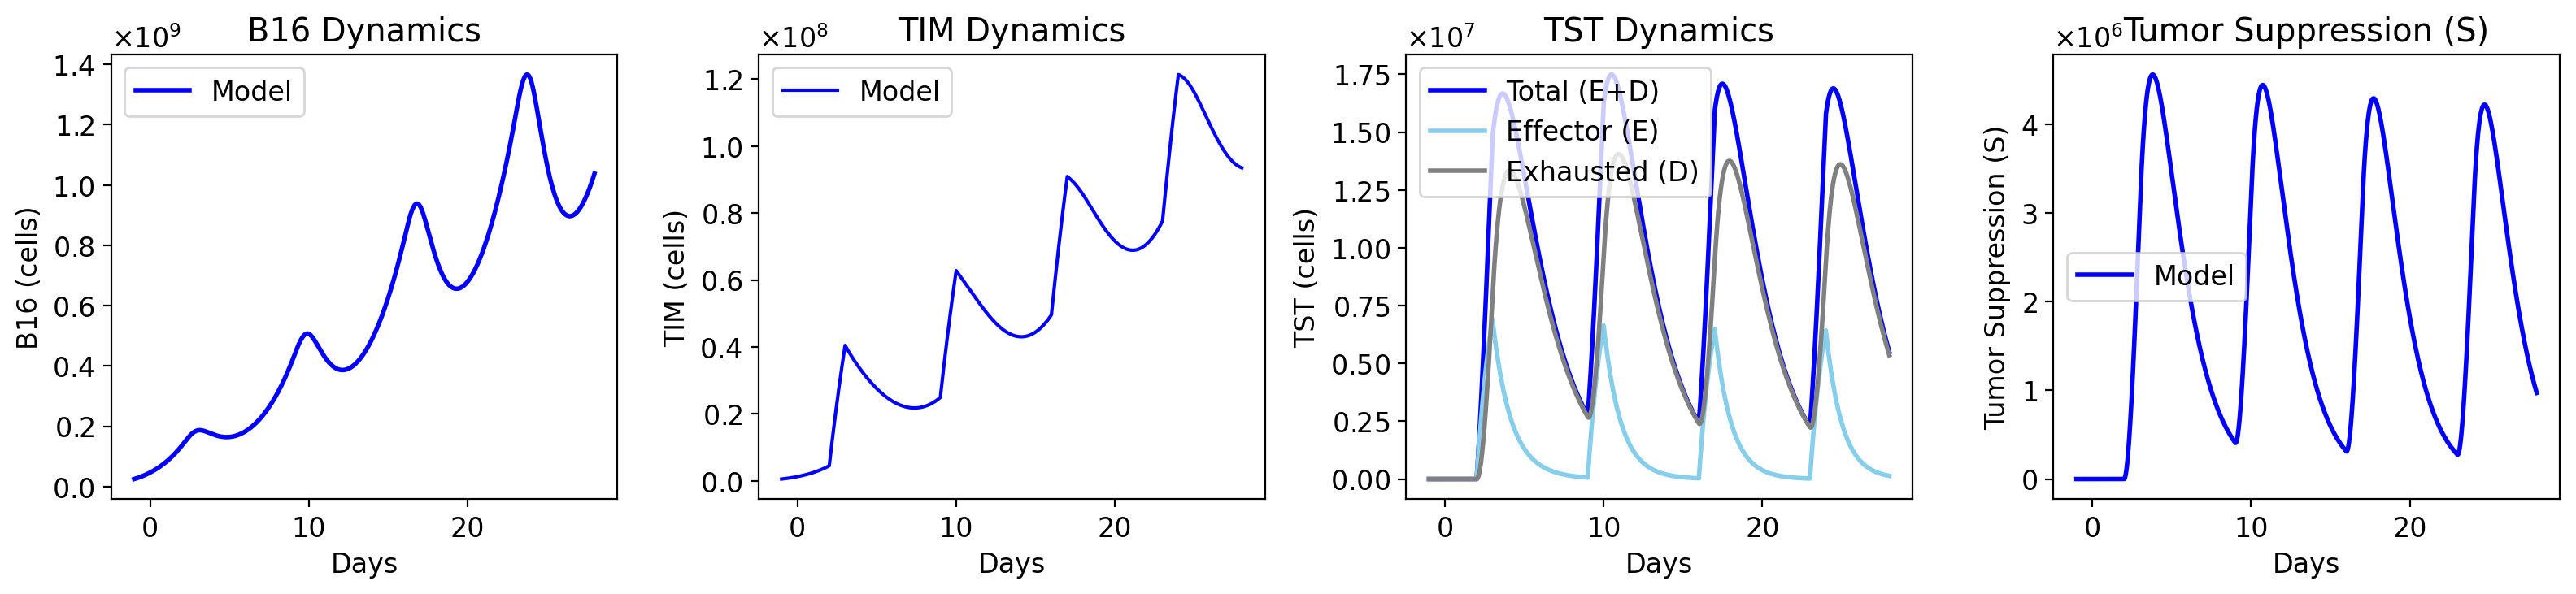

In [13]:
# Time range
y0 = [v_data[0], 0, 0, 0, mdsc_data[0]] # y = [V, E, D, S]
t_eval = np.arange(-1, 28.01, 0.01)

# Fixed TST injection schedule
dose_list = [1e7, 1e7, 1e7, 1e7] 
dose_days = [0, 7, 14, 21]    
delta_t = 1        

# === Model 1 Simulation ===
sol1 = odeint(model1, y0, t_eval, 
             args=(dose_list, dose_days, delta_t, param1))
V_sol1, E_sol1, D_sol1, S_sol1, M_sol1 = sol1.T
T_sol1 = E_sol1+D_sol1

# === Model 2 Simulation ===
sol2 = odeint(model2, y0, t_eval, 
             args=(dose_list, dose_days, delta_t, param2))
V_sol2, E_sol2, D_sol2, S_sol2, M_sol2 = sol2.T
T_sol2 = E_sol2+D_sol2

print("Model1")
vis_act(sol1, dir_path, "figSc")
print("Model2")
vis_act(sol2, dir_path, "figSd")